<a href="https://colab.research.google.com/github/Arx15E/IntegracionDatos/blob/main/Reto_integracion_multidimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

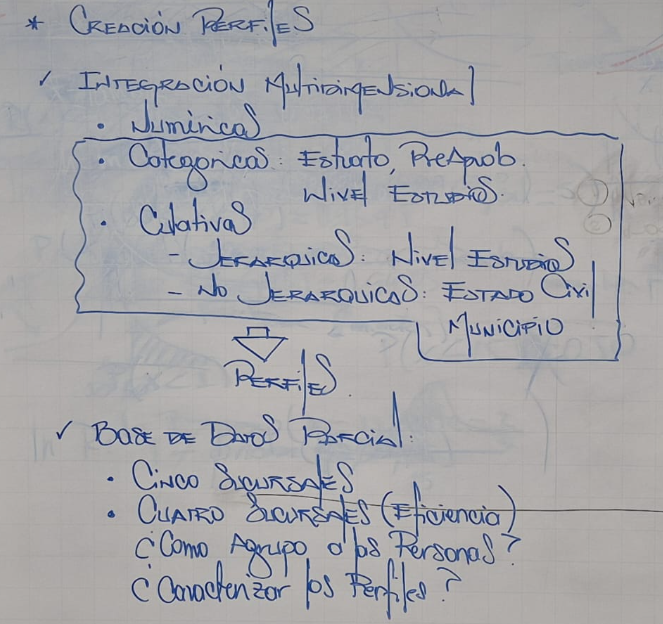

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# 1. Carga de datos
file_path = '/content/4. SolicitantesCrédito(USD)_Municipios (1).xlsx'
df_credit = pd.read_excel(file_path)

In [9]:
# 2. Selección de variables para la integración (según requerimiento)
# Edad, Hijos, Perscargo, Estrato, Ingresos, Egresos, Monto, Plazo y Cuota
variables_interes = [
    'Edad', 'Hijos', 'Perscargo', 'Estrato',
    'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)'
]

In [10]:
# Limpieza básica: Eliminamos nulos en las variables de interés
df_credit = df_credit.dropna(subset=variables_interes).reset_index(drop=True)


In [11]:
# 3. Preparación de matrices (Lógica del archivo base)
# XC: Semillas de Integración (primeros 5 solicitantes)
XC = np.array(df_credit[variables_interes].iloc[0:5, :], dtype=float)
# XD: Todos los datos para procesar
XD = np.array(df_credit[variables_interes], dtype=float)

In [12]:
# nc: Vector para almacenar la pertenencia a la sucursal
nc = np.zeros((len(XD), 1))

In [13]:
# 4. Proceso de Integración Multidimensional
# Se recorre cada registro para asignarlo a la sucursal más cercana y actualizarla
for k in range(len(XD)):
    Xind = XD[k, :]

In [14]:
# 4. Proceso de Integración Multidimensional
# Se recorre cada registro para asignarlo a la sucursal más cercana y actualizarla
for k in range(len(XD)):
    Xind = XD[k, :]

    # Cálculo de distancia (fórmula del archivo base: suma de diferencias relativas al cuadrado)
    # Agregamos un pequeño epsilon para evitar división por cero
    distancias = np.sum(((XC - Xind) / (XC + 1e-6))**2, axis=1)

    # Asignación al cluster (sucursal) más cercano
    cluster_asignado = int(np.argmin(distancias))
    nc[k] = cluster_asignado

    # Actualización del centroide (Integración de los datos: promedio entre el actual y el nuevo)
    XC[cluster_asignado, :] = (XC[cluster_asignado, :] + Xind) / 2

In [15]:
# Añadimos el resultado al DataFrame original
df_credit['Sucursal_Asignada'] = nc.astype(int)

--- RESULTADOS DE INTEGRACIÓN MULTIDIMENSIONAL ---
 Sucursal  Clientes  Pre-Aprobación (%)  Pre-Negación (%)   Municipios Principales
        0        86               41.86             58.14  Caldas, Sabaneta, Bello
        1       291               32.30             67.70 Caldas, Sabaneta, Itagüí
        2       226               44.69             55.31  Caldas, Sabaneta, Bello
        3        33               18.18             81.82 Caldas, Sabaneta, Itagüí
        4      5206               50.83             49.17  Sabaneta, Caldas, Bello


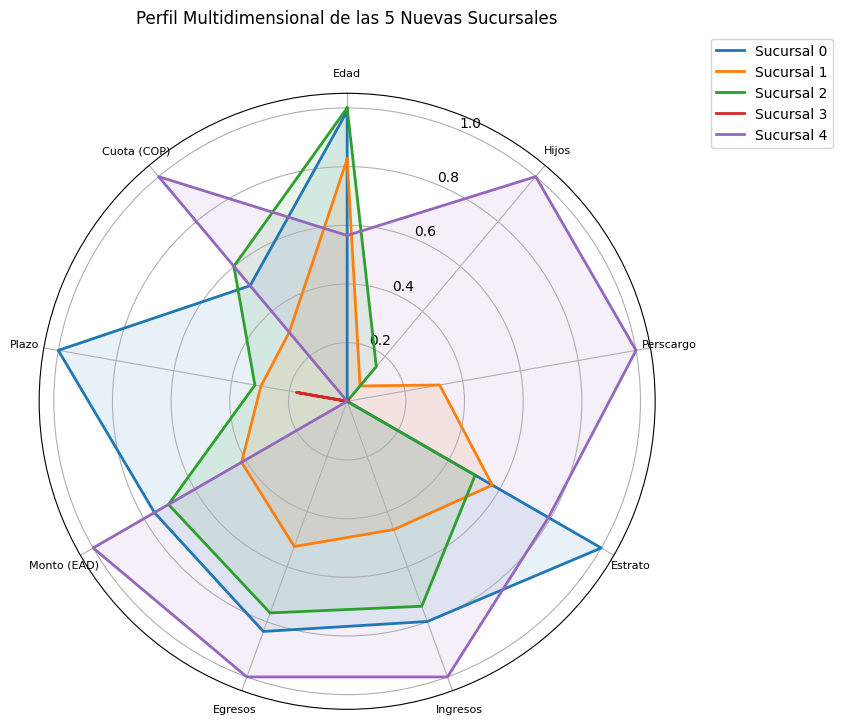

In [16]:
# 5. Análisis de Resultados (Abstracción solicitada)
print("--- RESULTADOS DE INTEGRACIÓN MULTIDIMENSIONAL ---")

resultados = []
for j in range(5):
    datos_sucursal = df_credit[df_credit['Sucursal_Asignada'] == j]
    num_clientes = len(datos_sucursal)

    # Cálculo de porcentajes de Preaprobación
    pre_aprobados = datos_sucursal['PreApr'].sum()
    porcentaje_pre = (pre_aprobados / num_clientes) * 100 if num_clientes > 0 else 0

    # Municipios principales
    municipios_top = datos_sucursal['Municipio'].value_counts().head(3).index.tolist()

    resultados.append({
        'Sucursal': j,
        'Clientes': num_clientes,
        'Pre-Aprobación (%)': round(porcentaje_pre, 2),
        'Pre-Negación (%)': round(100 - porcentaje_pre, 2),
        'Municipios Principales': ", ".join(municipios_top)
    })

# Mostrar tabla de resultados
df_resultados = pd.DataFrame(resultados)
print(df_resultados.to_string(index=False))

# 6. Representación Gráfica (Gráfico de Araña / Radar Chart)
# Preparamos los datos normalizados para el gráfico
df_perfil = df_credit.groupby('Sucursal_Asignada')[variables_interes].mean()
df_norm = (df_perfil - df_perfil.min()) / (df_perfil.max() - df_perfil.min())

labels = variables_interes
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(5):
    values = df_norm.iloc[i].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Sucursal {i}')
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=8)
plt.title('Perfil Multidimensional de las 5 Nuevas Sucursales', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()